# Import Libraries

In [45]:
import pandas as pd
import numpy as np
import re
import nltk
from nltk.tokenize import word_tokenize
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec
from multiprocessing import cpu_count
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.text import Tokenizer # type: ignore
from tensorflow.keras.preprocessing.sequence import pad_sequences # type: ignore
from tensorflow.keras.models import Sequential # type: ignore
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout # type: ignore


# Reading Data

In [3]:
df = pd.read_csv("WELFake_Dataset.csv")
print("Initial shape:", df.shape)
df.head()

Initial shape: (72134, 4)


,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


# EDA

In [4]:
print("\nLabel Distribution:")
print(df['label'].value_counts())
print("\nMissing Values:")
print(df.isnull().sum())


Label Distribution:
label
1    37106
0    35028
Name: count, dtype: int64

Missing Values:
Unnamed: 0      0
title         558
text           39
label           0
dtype: int64


# Data Preprocessing

In [9]:
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\tech\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\tech\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\tech\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


True

In [ ]:
en_stop = set(nltk.corpus.stopwords.words('english')) 

def clean_text(text):

    text = str(text).lower()

    text = re.sub(r'[^a-zA-Z]', ' ', text)

    text = re.sub(r'\s+', ' ', text)
    
    tokens = word_tokenize(text)
    clean_tokens = [word for word in tokens if word not in en_stop]

    return " ".join(clean_tokens)

In [11]:
df['content'] = df['title'].fillna('') + " " + df['text'].fillna('')
df['content'] = df['content'].apply(clean_text)
df = df[['content', 'label']]
df.dropna(inplace=True)
print("\nAfter Cleaning:", df.shape)


After Cleaning: (72134, 2)


In [12]:
df.head()

,content,label
0,law enforcement on high alert following threat...,1
1,did they post their votes for hillary already,1
2,unbelievable obama s attorney general says mos...,1
3,bobby jindal raised hindu uses story of christ...,0
4,satan russia unvelis an image of its terrifyin...,1


# Train-Test Split

In [ ]:
X = df['content']
y = df['label']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

#  Feature Extraction 

# 1- TF-IDF


In [ ]:
print("\nVectorizing text...")
vectorizer = TfidfVectorizer(
    max_df=0.8,
    min_df=5,
    ngram_range=(1,2),
    max_features=60000
)
X_train_tf_idf = vectorizer.fit_transform(X_train)
X_test_tf_idf = vectorizer.transform(X_test)

print("Vector shape:", X_train_tf_idf.shape)


Vectorizing text...
Vector shape: (57707, 60000)


# 2-Word2Vec

In [29]:
cpu = cpu_count()
print('The virtual instance has {} cpus, that will be used to train the word2vec model'.format(cpu))
print("Training the fake news W2V model...")
w2v_model = Word2Vec(sentences=X_train, vector_size=100, window=5, min_count=3, workers=cpu)
w2v_model.train(X_train, total_examples=len(X_train), epochs=10)
wv = w2v_model.wv


The virtual instance has 8 cpus, that will be used to train the word2vec model
Training the fake news W2V model...


In [30]:
def get_document_vector(tokens, model, vector_size):
    vectors = [model.wv[word] for word in tokens if word in model.wv]
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

X_train_w2v_vectors = np.array([get_document_vector(text, w2v_model, 100) for text in X_train])
X_test_w2v_vectors = np.array([get_document_vector(text, w2v_model, 100) for text in X_test])

# LogisticRegression
#       1- tf-idf LogisticRegression

Accuracy:  0.9544603867747973
Results for TF-IDF + Logistic Regression:
              precision    recall  f1-score   support

           0       0.96      0.94      0.95      7006
           1       0.95      0.97      0.96      7421

    accuracy                           0.95     14427
   macro avg       0.95      0.95      0.95     14427
weighted avg       0.95      0.95      0.95     14427



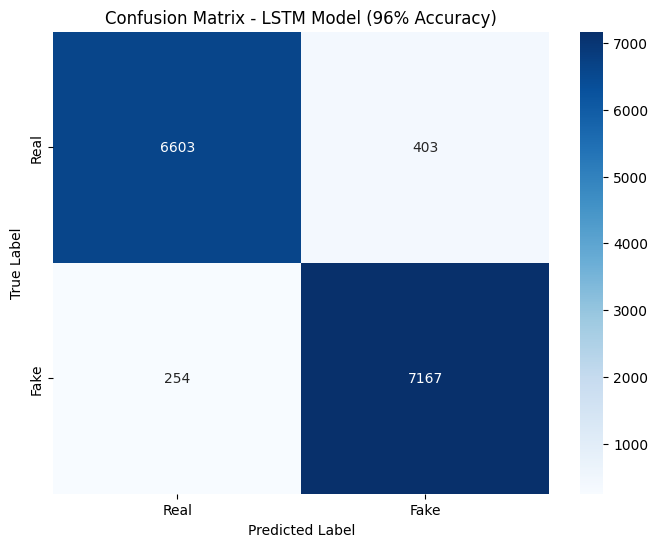

In [47]:
lr_tf_idf = LogisticRegression()
lr_tf_idf.fit(X_train_tf_idf, y_train)
y_pred_tf_idf = lr_tf_idf.predict(X_test_tf_idf)
acc = accuracy_score(y_test, y_pred_tf_idf)
print("Accuracy: ", acc)

print("Results for TF-IDF + Logistic Regression:")
print(classification_report(y_test, y_pred_tf_idf))
cm =confusion_matrix(y_test, y_pred_tf_idf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Real', 'Fake'], 
            yticklabels=['Real', 'Fake'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - LSTM Model (96% Accuracy)')
plt.show()

# LSTM


In [38]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
max_length = 300
X_train_pad = pad_sequences(X_train_seq, maxlen=max_length, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_length, padding='post')

vocab_size = len(tokenizer.word_index) + 1

In [39]:
embedding_matrix = np.zeros((vocab_size, 100)) 
for word, i in tokenizer.word_index.items():
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]

In [43]:
model = Sequential([
    Embedding(vocab_size, 100, weights=[embedding_matrix], input_length=max_length, trainable=True),
    
    LSTM(128, dropout=0.2),
    
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid') ])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

print("Starting LSTM training on GPU...")
history = model.fit(X_train_pad, y_train, 
                    epochs=3, 
                    batch_size=64, 
                    validation_data=(X_test_pad, y_test))

c:\Users\tech\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Starting LSTM training on GPU...
Epoch 1/3
902/902 ━━━━━━━━━━━━━━━━━━━━ 349s 384ms/step - accuracy: 0.7933 - loss: 0.3917 - val_accuracy: 0.7731 - val_loss: 0.3979
Epoch 2/3
902/902 ━━━━━━━━━━━━━━━━━━━━ 363s 403ms/step - accuracy: 0.8187 - loss: 0.3375 - val_accuracy: 0.9275 - val_loss: 0.1948
Epoch 3/3
902/902 ━━━━━━━━━━━━━━━━━━━━ 359s 398ms/step - accuracy: 0.9654 - loss: 0.1037 - val_accuracy: 0.9596 - val_loss: 0.1209


451/451 ━━━━━━━━━━━━━━━━━━━━ 34s 75ms/step
Final LSTM Accuracy: 95.95896582796146%

Classification Report for LSTM:
              precision    recall  f1-score   support

           0       0.95      0.96      0.96      7006
           1       0.97      0.95      0.96      7421

    accuracy                           0.96     14427
   macro avg       0.96      0.96      0.96     14427
weighted avg       0.96      0.96      0.96     14427



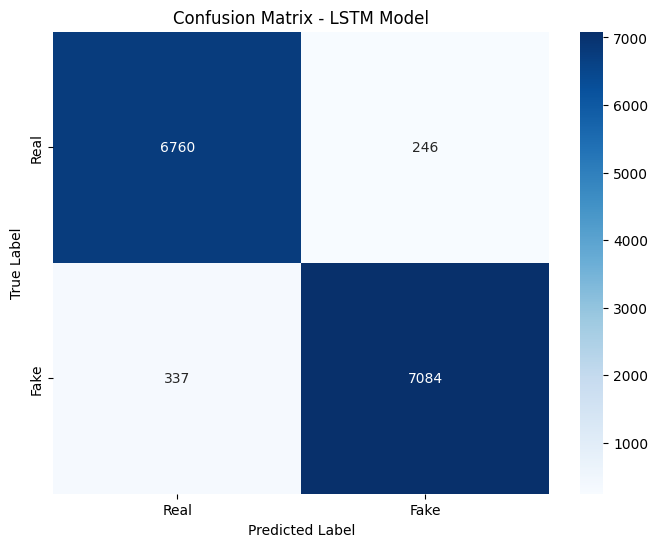

In [49]:
y_pred_probs = model.predict(X_test_pad)
y_pred_lstm = (y_pred_probs > 0.5).astype("int32")

acc = accuracy_score(y_test, y_pred_lstm)
print(f"Final LSTM Accuracy: {acc * 100}%")

print("\nClassification Report for LSTM:")
print(classification_report(y_test, y_pred_lstm))
cm = confusion_matrix(y_test, y_pred_lstm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Real', 'Fake'], 
            yticklabels=['Real', 'Fake'])

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - LSTM Model')
plt.show()


In [50]:
import pickle
import os

project_path = r'D:\nlp\project'

model.save(os.path.join(project_path, 'LSTM_Final_96.h5'))

with open(os.path.join(project_path, 'tokenizer.pkl'), 'wb') as handle:
    pickle.dump(tokenizer, handle, protocol=pickle.HIGHEST_PROTOCOL)

print("done save")

done save
